In [1]:
import time
from functools import partial
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# Set a random seed for reproducibility
key = jax.random.PRNGKey(42)

## Problem Overview: Cauchy-Euler Equation

We are solving the following second-order ODE using a JAX-based PINN:
$$x^2 \frac{d^2y}{dx^2} - 2x \frac{dy}{dx} + 2y = 0$$

**Parameters and Domain:**
- **Domain**: $x \in [1, 2]$
- **Conditions**: $y(1) = 0, y'(1) = 1$
- **Exact Solution**: $y(x) = x^2 - x$

In [2]:
def exact_solution(x):
    """Computes the analytical solution: y = x^2 - x"""
    return x**2 - x

def plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch):
    """Plots the PINN's prediction vs exact solution"""
    test_error = jnp.mean(jnp.abs(y_test_batch - y_exact_batch) / y_exact_batch.std())
    plt.figure(figsize=(8,3))
    plt.scatter(x_physics_batch[:,0], jnp.zeros_like(x_physics_batch)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
    plt.scatter(x_boundary, 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point (x=1)")
    plt.plot(x_test_batch[:,0], y_exact_batch[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x_test_batch[:,0], y_test_batch[:,0], label="PINN solution", color="tab:green")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Step {i} | Relative L1 Error: {test_error:.2%}")
    plt.legend()
    plt.show()

In [3]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        """Forward pass for a SINGLE input point x"""
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)

        # Last layer with no activation
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [4]:
def PINN_physics_loss(parameters, x, network):
    """Compute x^2*y'' - 2x*y' + 2y = 0"""
    def y_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()
    y = y_fn(x_val)
    dydx = jax.grad(y_fn)(x_val)
    d2ydx2 = jax.grad(jax.grad(y_fn))(x_val)

    # Residual of the Cauchy-Euler equation
    loss_physics = (x_val**2 * d2ydx2) - (2 * x_val * dydx) + (2 * y)
    return loss_physics**2

def PINN_boundary_losses(parameters, x, network):
    """Enforce y(1)=0 and y'(1)=1"""
    def y_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()
    y = y_fn(x_val)
    dydx = jax.grad(y_fn)(x_val)

    loss_y = (y - 0.0)**2
    loss_y_prime = (dydx - 1.0)**2
    return loss_y, loss_y_prime

def PINN_loss_batch(parameters, x_boundary, x_physics_batch, network):
    # Vectorize physics loss over the batch of x points
    loss_physics_batch = jax.vmap(PINN_physics_loss, in_axes=(None, 0, None))(parameters, x_physics_batch, network)
    loss_physics = jnp.mean(loss_physics_batch)

    # Boundary losses at x=1
    loss_y, loss_y_prime = PINN_boundary_losses(parameters, x_boundary, network)

    # Total loss with weighting
    return 1e-3*loss_physics + loss_y + loss_y_prime

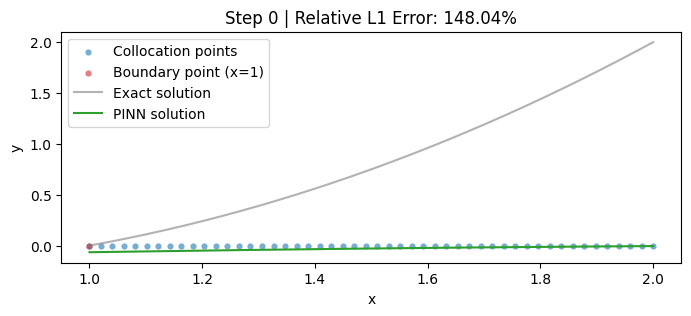

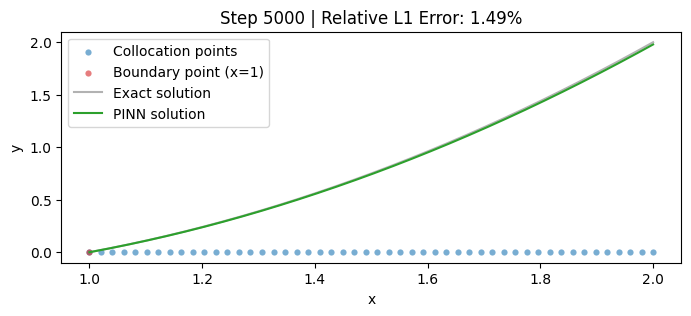

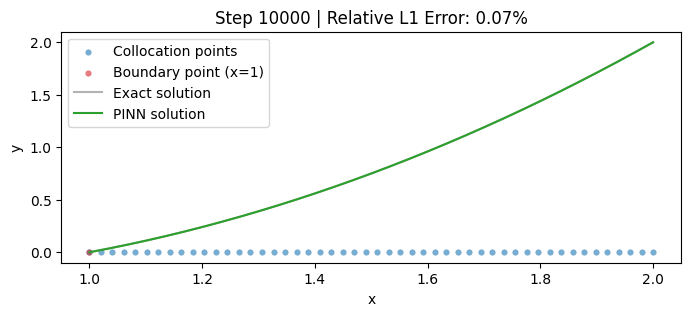

Total training time: 7.99 seconds


In [6]:
@partial(jax.jit, static_argnums=(1, 5))
def PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network):
    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        parameters, x_boundary, x_physics_batch, network)
    updates, opt_state = optimiser.update(grads, opt_state, parameters)
    parameters = optax.apply_updates(parameters, updates)
    return loss, opt_state, parameters

# Setup Data
x_boundary = jnp.array([1.0])
x_physics_batch = jnp.linspace(1, 2, 50).reshape(-1, 1)
x_test_batch = jnp.linspace(1, 2, 300).reshape(-1, 1)
y_exact_batch = jax.vmap(exact_solution)(x_test_batch)

# Initialize Network
network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(parameters)

# Training Loop
start = time.time()
for i in range(10001):
    loss, opt_state, parameters = PINN_step(
        opt_state, optimiser, parameters, x_boundary, x_physics_batch, network)

    if i % 5000 == 0:
        y_test_batch = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_test_batch)
        plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch)

print(f"Total training time: {time.time()-start:.2f} seconds")

Task 2 - Inverse Problem in JAX

The Goal in this task, we assume that the coefficient of the first derivative term in our Cauchy-Euler equation is unknown. We represent the equation as:$$x^2 \frac{d^2y}{dx^2} + \alpha x \frac{dy}{dx} + 2y = 0$$


---


Our objective is to use noisy observations of $y(x)$ to find the true value of $\alpha$ (which is $-2.0$).The JAX ImplementationIn JAX, we treat $\alpha$ as a separate array that is passed into the loss function. We then use `jax.value_and_grad` to calculate gradients for both the network parameters and the scalar alpha. This is a functional approach compared to PyTorch's `nn.Parameter`.

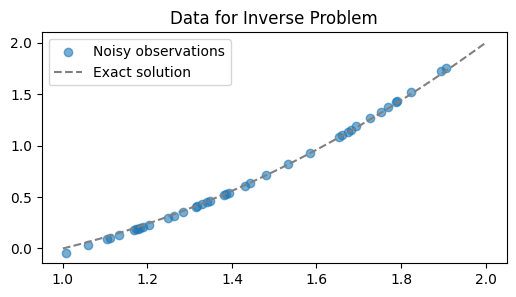

In [7]:
# 1. Create noisy observational data
key, subkey = jax.random.split(key)
x_obs = (1.0 + jax.random.uniform(subkey, (40, 1))) # Domain [1, 2]
y_obs = exact_solution(x_obs) + 0.02 * jax.random.normal(subkey, (40, 1))

plt.figure(figsize=(6, 3))
plt.scatter(x_obs, y_obs, label="Noisy observations", color="tab:blue", alpha=0.6)
plt.plot(jnp.linspace(1, 2, 100), exact_solution(jnp.linspace(1, 2, 100)),
         label="Exact solution", color="grey", linestyle="--")
plt.legend()
plt.title("Data for Inverse Problem")
plt.show()

In [8]:
def PINN_inverse_physics_loss(parameters, alpha, x, network):
    """Physics residual: x^2*y'' + alpha*x*y' + 2y = 0"""
    def y_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()
    y = y_fn(x_val)
    dydx = jax.grad(y_fn)(x_val)
    d2ydx2 = jax.grad(jax.grad(y_fn))(x_val)

    # ODE residual using the learnable alpha
    residual = (x_val**2 * d2ydx2) + (alpha * x_val * dydx) + (2 * y)
    return residual**2

def PINN_inverse_loss_batch(params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    # Unpack the combined parameters
    parameters, alpha = params_and_alpha

    # 1. Physics Loss
    loss_physics = jnp.mean(jax.vmap(PINN_inverse_physics_loss, in_axes=(None, None, 0, None))(
        parameters, alpha, x_physics_batch, network))

    # 2. Data Loss (Matching noisy observations)
    y_pred_obs = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_obs)
    loss_data = jnp.mean((y_pred_obs - y_obs)**2)

    # Return weighted sum
    return loss_physics + 1e4 * loss_data

Step 0 | Loss: 6.1154e+03 | Estimated alpha: -0.0010
Step 5000 | Loss: 1.4334e-01 | Estimated alpha: -1.8862
Step 10000 | Loss: 1.0620e-01 | Estimated alpha: -1.9120
Step 15000 | Loss: 9.3194e-02 | Estimated alpha: -1.9158


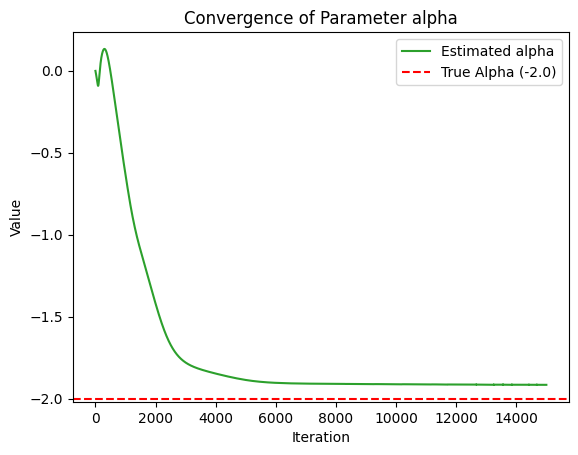

In [11]:
@partial(jax.jit, static_argnums=(1, 6))
def inverse_step(opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=0)(
        params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    updates, opt_state = optimiser.update(grads, opt_state, params_and_alpha)
    params_and_alpha = optax.apply_updates(params_and_alpha, updates)

    return loss, opt_state, params_and_alpha

# Initialize
network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
alpha_init = jnp.array(0.0) # Initial guess for alpha
params_and_alpha = (parameters, alpha_init)

optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(params_and_alpha)

# Loop
alphas = []
for i in range(15001):
    loss, opt_state, params_and_alpha = inverse_step(
        opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    current_alpha = params_and_alpha[1]
    alphas.append(current_alpha)

    if i % 5000 == 0:
        print(f"Step {i} | Loss: {loss:.4e} | Estimated alpha: {current_alpha:.4f}")

# Final Plot
plt.plot(alphas, label="Estimated alpha", color="tab:green")
plt.axhline(y=-2.0, color="red", linestyle="--", label="True Alpha (-2.0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.title("Convergence of Parameter alpha")
plt.show()